In [1]:
# These are data handling libraries
import numpy as np
import pandas as pd

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
# Check which columns have NaN values. These is for linear regression
missing_values = train_df.isnull().sum()
print(missing_values[missing_values > 0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [5]:
# Cleaning the data for linear regression by removing NaN values to provide better representation, which will also assist with one-hot encoding later on.

train_df['LotFrontage'] = train_df['LotFrontage'].fillna(0) #might no use this one.
train_df['Alley'] = train_df['Alley'].fillna('No Alley')
train_df['MasVnrType'] = train_df['MasVnrType'].fillna('None')
train_df['MasVnrArea'] = train_df['MasVnrArea'].fillna(0)

basement_columns = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for column in basement_columns:
    train_df[column] = train_df[column].fillna('No Basement')

train_df['Electrical'] = train_df['Electrical'].fillna(train_df['Electrical'].mode()[0])
train_df['FireplaceQu'] = train_df['FireplaceQu'].fillna('No Fireplace')

garage_columns = ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
for column in garage_columns:
    train_df[column] = train_df[column].fillna('No Garage')

train_df['PoolQC'] = train_df['PoolQC'].fillna('No Pool')
train_df['Fence'] = train_df['Fence'].fillna('No Fence')
train_df['MiscFeature'] = train_df['MiscFeature'].fillna('No Misc Feature')


In [6]:
missing_values = train_df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [7]:
# List the columns that are numerical
numerical_columns_before = train_df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns before encoding:", numerical_columns_before)


categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns

# Display the categorical columns
print("categoricalcolumns before encoding:", categorical_columns)

Numerical columns before encoding: Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
categoricalcolumns before encoding: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposu

In [8]:
categorical_columns = [col for col in categorical_columns if col != 'GarageYrBlt']

# One-hot encode the categorical columns
train_df = pd.get_dummies(train_df, columns=categorical_columns, drop_first=True)

# List the columns that are numerical
numerical_columns_before = train_df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns after encoding:", numerical_columns_before)


categorical_columns = train_df.select_dtypes(include=['object', 'category']).columns

# Display the categorical columns
print("categoricalcolumns after encoding:", categorical_columns)

Numerical columns after encoding: Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')
categoricalcolumns after encoding: Index(['GarageYrBlt'], dtype='object')


In [9]:
train_df = train_df.drop(columns=['GarageYrBlt'])

In [10]:
# Calculate the correlation matrix
corr_matrix = train_df.corr()

# Display the correlation with SalePrice
print(corr_matrix['SalePrice'].sort_values(ascending=False))


SalePrice                   1.000000
OverallQual                 0.790982
GrLivArea                   0.708624
GarageCars                  0.640409
GarageArea                  0.623431
                              ...   
GarageFinish_Unf           -0.410608
BsmtQual_TA                -0.452394
FireplaceQu_No Fireplace   -0.471908
KitchenQual_TA             -0.519298
ExterQual_TA               -0.589044
Name: SalePrice, Length: 260, dtype: float64


In [11]:
weak_corr_columns = corr_matrix.columns[corr_matrix['SalePrice'].between(-0.2, 0.2)]

# Drop these columns
train_df.drop(weak_corr_columns, axis=1, inplace=True)

# Print the remaining columns
print(train_df.columns)

Index(['LotFrontage', 'LotArea', 'OverallQual', 'YearBuilt', 'YearRemodAdd',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'GrLivArea', 'BsmtFullBath', 'FullBath', 'HalfBath',
       'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'SalePrice', 'MSZoning_RL', 'MSZoning_RM',
       'LotShape_Reg', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_StoneBr', 'HouseStyle_2Story', 'RoofStyle_Gable',
       'RoofStyle_Hip', 'Exterior1st_VinylSd', 'Exterior2nd_VinylSd',
       'MasVnrType_None', 'MasVnrType_Stone', 'ExterQual_Gd', 'ExterQual_TA',
       'Foundation_CBlock', 'Foundation_PConc', 'BsmtQual_Gd', 'BsmtQual_TA',
       'BsmtExposure_Gd', 'BsmtExposure_No', 'BsmtFinType1_GLQ',
       'HeatingQC_TA', 'CentralAir_Y', 'Electrical_SBrkr', 'KitchenQual_Gd',
       'KitchenQual_TA', 'FireplaceQu_Gd', 'FireplaceQu_No Fireplace',
       'GarageType_Attchd', 'GarageType_BuiltIn', '

In [12]:
# These are visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

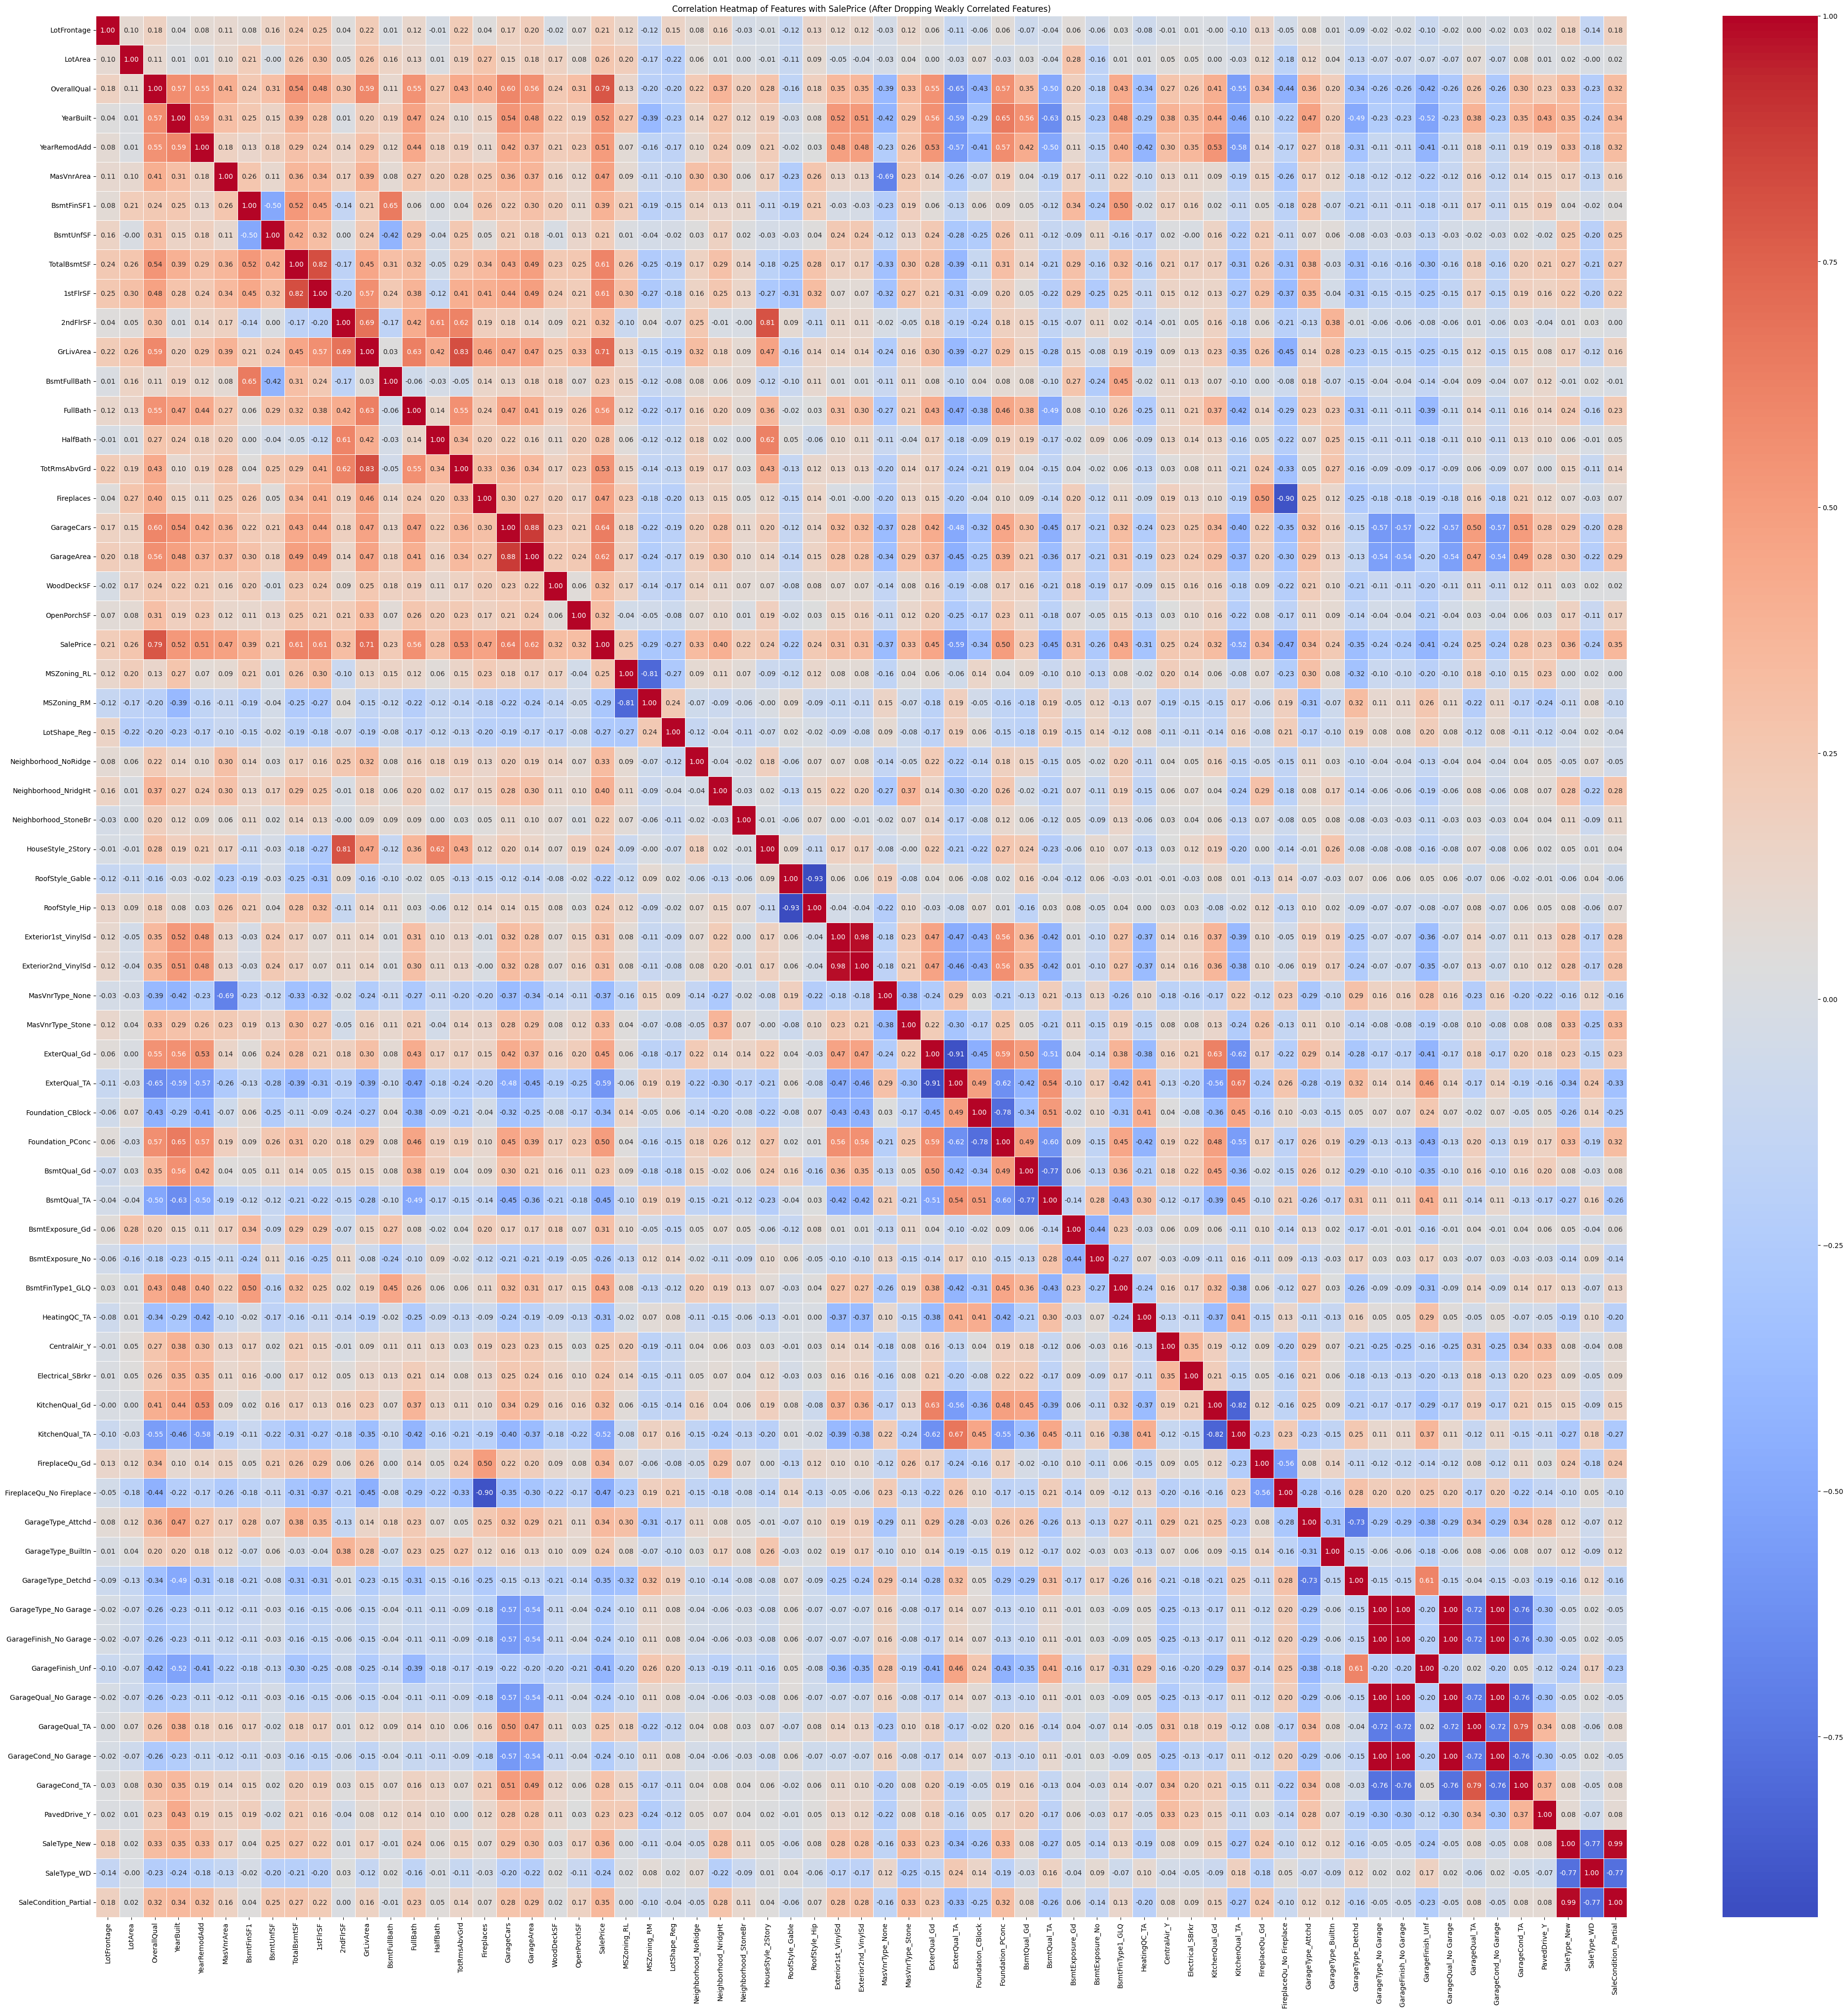

In [13]:
# Calculate the new correlation matrix after dropping weak columns from before
new_corr_matrix = train_df.corr()

# Set a figure size for better visibility
plt.figure(figsize=(50, 50))

# Plot the heatmap
sns.heatmap(new_corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Display the plot
plt.title('Correlation Heatmap of Features with SalePrice (After Dropping Weakly Correlated Features)')
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [15]:
X = train_df.drop('SalePrice', axis=1)  # Features (everything except SalePrice)
y = train_df['SalePrice']  # Target variable (SalePrice)

# Train-test split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


In [16]:
# Initialize the model
model = LinearRegression()

In [17]:
# Train the model on the training data
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")


Root Mean Squared Error (RMSE): 44861.861750704826
R² Score: 0.7101678181429101


/opt/anaconda3/envs/r-tutorial/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


<h3>For the method above, we used a Linear Regression model to train the system for predicting house prices. As shown, the Root Mean Squared Error (RMSE) was 34,710.89, meaning that the predictions were off by approximately $34,710.89 on average. The R² score was 78.5%, indicating that the model explains about 78.5% of the variance in the house prices. This suggests that the model had moderate success. However, there may be a better approach to tackle this problem, and for that, we will use XGBOOST which is  Extreme Gradient Boosting</h3>

In [22]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


In [23]:
# Load the data
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

### Data Preprocessing and Feature Engineering
- Filled missing values in basement and floor square footage columns (`TotalBsmtSF`, `1stFlrSF`, `2ndFlrSF`) with 0.
- Created a new feature `TotalSF`, which is the sum of the basement, 1st floor, and 2nd floor square footage.

In [24]:
train_df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']] = train_df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].fillna(0)
test_df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']] = test_df[['TotalBsmtSF', '1stFlrSF', '2ndFlrSF']].fillna(0)

# Feature Engineering: Creating TotalSF (Total Square Feet)
train_df['TotalSF'] = train_df['TotalBsmtSF'] + train_df['1stFlrSF'] + train_df['2ndFlrSF']
test_df['TotalSF'] = test_df['TotalBsmtSF'] + test_df['1stFlrSF'] + test_df['2ndFlrSF']

### Log Transformation of `TotalSF`
- Applied a log transformation (`np.log1p`) to the `TotalSF` feature to reduce skewness.
- Plotted a histogram with a KDE to visualize the distribution of the log-transformed `TotalSF`.


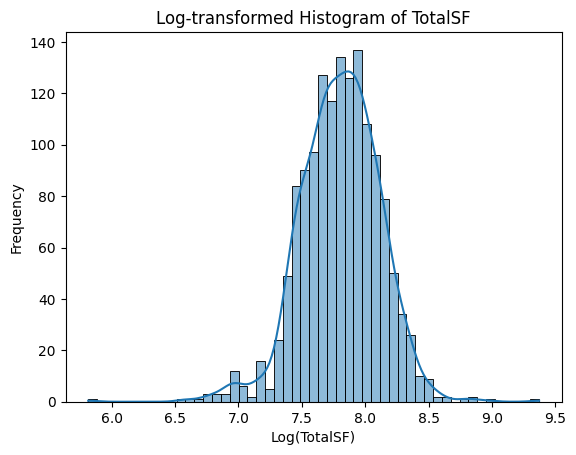

In [25]:
train_df['TotalSF_log'] = np.log1p(train_df['TotalSF'])
sns.histplot(train_df['TotalSF_log'], kde=True)
plt.title("Log-transformed Histogram of TotalSF")
plt.xlabel("Log(TotalSF)")
plt.ylabel("Frequency")
plt.show()

### Visualizing Relationship Between `TotalSF` and Log-transformed `SalePrice`
- Created a scatterplot to examine the relationship between `TotalSF` (square footage) and log-transformed `SalePrice`.
- Applied gridlines for better readability and included appropriate axis labels and title.


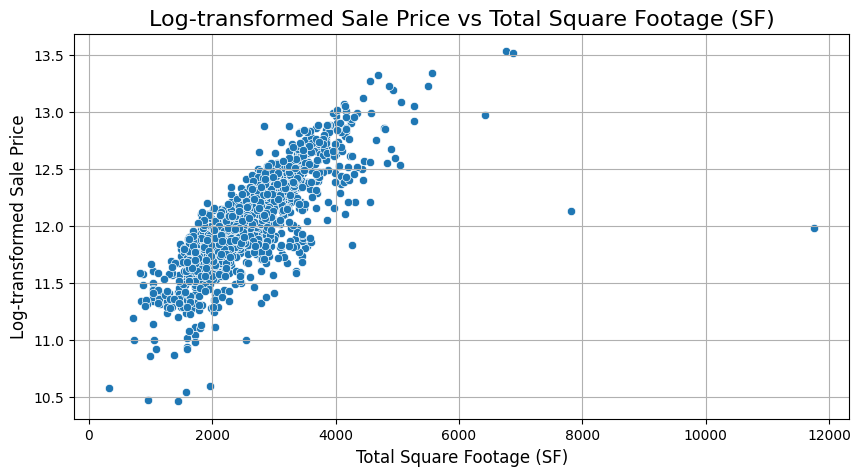

In [26]:
plt.figure(figsize=(10, 5))

sns.scatterplot(x="TotalSF", y=np.log(train_df["SalePrice"]), data=train_df)
plt.title("Log-transformed Sale Price vs Total Square Footage (SF)", fontsize=16)
plt.xlabel("Total Square Footage (SF)", fontsize=12)
plt.ylabel("Log-transformed Sale Price", fontsize=12)

# This is for better readability
plt.grid(True)
plt.show()


### Outlier Removal Using IQR Method
- Calculated the **Interquartile Range (IQR)** for the `TotalSF` feature.
- Defined the lower and upper bounds based on 1.5 times the IQR to identify outliers.
- Filtered out rows where `TotalSF` values were outside these bounds to remove outliers.


In [27]:
Q1 = train_df['TotalSF'].quantile(0.25)
Q3 = train_df['TotalSF'].quantile(0.75)

# Calculate Interquartile Range (IQR)
IQR = Q3 - Q1

# Define the lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out rows where TotalSF is an outlier
train_df = train_df[(train_df['TotalSF'] >= lower_bound) & (train_df['TotalSF'] <= upper_bound)]

### Boxplot of `OverallQual` vs Log-transformed `SalePrice`
- Created a boxplot to visualize the distribution of log-transformed `SalePrice` across different levels of `OverallQual`.


/var/folders/c0/76_2l7td5rvbwgrtp098vf540000gp/T/ipykernel_23606/4031187757.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="OverallQual", y=np.log(train_df["SalePrice"]), data=train_df, palette="Set2")


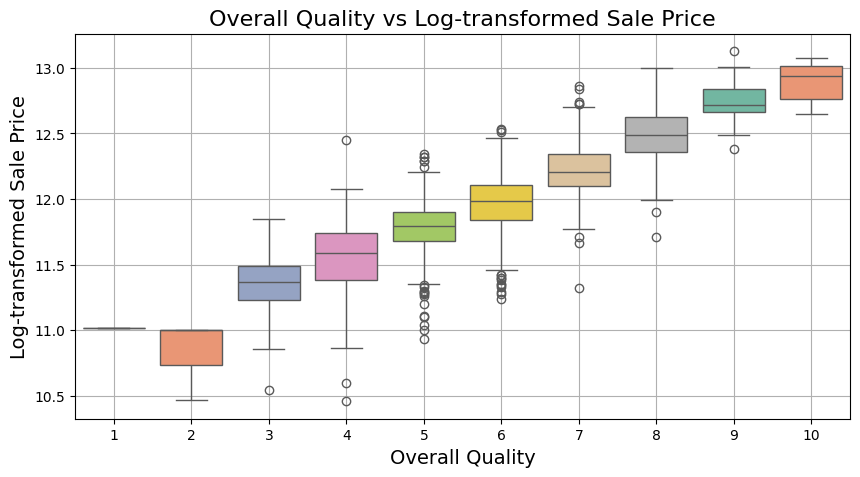

In [28]:
plt.figure(figsize=(10, 5))

sns.boxplot(x="OverallQual", y=np.log(train_df["SalePrice"]), data=train_df, palette="Set2")

plt.title("Overall Quality vs Log-transformed Sale Price", fontsize=16)
plt.xlabel("Overall Quality", fontsize=14)
plt.ylabel("Log-transformed Sale Price", fontsize=14)
plt.grid(True)
plt.show()


### Correlation Analysis and Heatmap of Top Features
- Applied **one-hot encoding** to categorical features using `pd.get_dummies()`.
- Computed the **correlation matrix** and selected the top 10 features most correlated with `SalePrice`.
- Visualized the correlations using a heatmap to better understand the relationships between the most influential features and `SalePrice`.

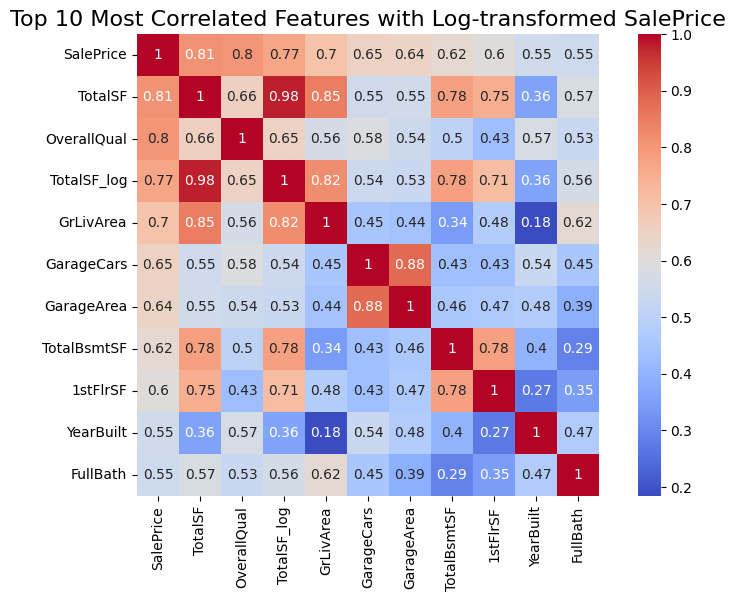

In [29]:
train_df_encoded = pd.get_dummies(train_df)

corr_matrix = train_df_encoded.corr()

top_corr_features = corr_matrix['SalePrice'].nlargest(11).index

plt.figure(figsize=(10, 6))
sns.heatmap(train_df_encoded[top_corr_features].corr(), annot=True, cmap="coolwarm", square=True)
plt.title("Top 10 Most Correlated Features with Log-transformed SalePrice", fontsize=16)
plt.show()

### Data Preprocessing Function
- **Dropped the 'Id' column** as it is not useful for modeling.
- **Separated numerical and categorical features** for specific preprocessing.
- Applied **imputation** for missing values in both numerical and categorical features:
  - Numerical features: filled missing values with the median.
  - Categorical features: filled missing values with the string "missing".
- **Standardized numerical features** using `StandardScaler` and **one-hot encoded categorical features**.
- Used a **ColumnTransformer** to apply the appropriate transformations to numerical and categorical data.


In [30]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

def preprocess_data(df, is_train=True):
    # Drop the 'Id' column
    if "Id" in df.columns:
        df = df.drop(["Id"], axis=1)

    num_features = df.select_dtypes(include=[np.number]).columns
    cat_features = df.select_dtypes(include=[object]).columns

    if is_train:
        num_features = num_features.drop("SalePrice")

    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
    ])

    full_preprocessor = ColumnTransformer([
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ])

    df_preprocessed = full_preprocessor.fit_transform(df)

    return df_preprocessed, num_features, cat_features

train_df_processed, train_num_features, train_cat_features = preprocess_data(train_df)
test_df_processed, test_num_features, test_cat_features = preprocess_data(test_df, is_train=False)

### Preprocessing Setup for Features
- **Separated features (`X`) and target (`y`)**: Dropped `SalePrice` for features (`X`) and log-transformed `SalePrice` for the target (`y`).
- Created preprocessing pipelines for:
  - **Numerical features**: Imputed missing values with the mean and standardized using `StandardScaler`.
  - **Categorical features**: Imputed missing values with the most frequent value and applied one-hot encoding.
- Used a **ColumnTransformer** to apply the appropriate transformations to both numerical and categorical features.


In [31]:
X = train_df.drop("SalePrice", axis=1)
y = np.log(train_df["SalePrice"])

# Preprocessing pipeline for numerical features
num_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="mean")), ("scaler", StandardScaler())]
)

# Preprocessing pipeline for categorical features
cat_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]
)

# ColumnTransformer to apply transformations for both numerical and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_transformer, train_num_features),  # Apply to numerical columns for both train and test
        ("cat", cat_transformer, train_cat_features),  # Apply to categorical columns for both train and test
    ],
    remainder="drop",
)


### XGBoost Model Creation and Grid Search
- **XGBoost Model**: Created an `XGBRegressor` with `reg:squarederror` for regression tasks.
- **Pipeline Setup**: Combined preprocessing and model fitting into a single pipeline using `Pipeline()`.
- **Hyperparameter Tuning**: Defined a parameter grid to tune key hyperparameters, including:
  - Learning rate, number of estimators, max depth, and subsample ratio.
- **Grid Search**: Performed a grid search with 5-fold cross-validation (`GridSearchCV`) to find the best model parameters using RMSE as the evaluation metric.
- **Test Data Predictions**: Used the best model from the grid search to predict `SalePrice` on the test data, reversing the log transformation on predictions.
- **Submission**: Created a submission DataFrame with predictions and saved it as `submission.csv`.


In [32]:
# Create an XGBoost model
model_xgb = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)
pipeline_xgb = Pipeline(steps=[("preprocessor", preprocessor), ("model", model_xgb)])

In [33]:
param_grid = {
    "model__learning_rate": [0.01, 0.1],
    "model__n_estimators": [100, 500, 1000],
    "model__max_depth": [3, 6],
    "model__subsample": [0.5, 1],
}

In [34]:
# Perform Grid Search
grid_search = GridSearchCV(pipeline_xgb, param_grid, scoring="neg_root_mean_squared_error", cv=5, verbose=1, n_jobs=-1)
grid_search.fit(X, y)
r2_score = grid_search.best_estimator_.score(X, y)

# Best parameters, RMSE score, and R² score
print("Best parameters found: ", grid_search.best_params_)
print("Best RMSE score found: ", -grid_search.best_score_)
print("R² score: ", r2_score)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found:  {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 1000, 'model__subsample': 0.5}
Best RMSE score found:  0.1157225296328804
R² score:  0.9545875821426912


In [35]:
# Ensure 'TotalSF_log' is created in the test data
test_df['TotalSF_log'] = np.log1p(test_df['TotalSF'])

# Now use the best model from the grid search to make predictions
test_predictions = grid_search.best_estimator_.predict(test_df)

# Invert the log transformation on predictions
test_saleprice = np.exp(test_predictions)

# Create a submission DataFrame
submission_df = pd.DataFrame({'Id': pd.read_csv('test.csv')['Id'], 'SalePrice': test_saleprice})

# Print the DataFrame
print(submission_df.head())

# Save the submission DataFrame as a CSV file
submission_df.to_csv('submission.csv', index=False)


     Id      SalePrice
0  1461  125218.070312
1  1462  160722.625000
2  1463  184159.250000
3  1464  192225.375000
4  1465  186649.296875


<h3> Based on this project, it is clear that XGBoost provided better prediction results compared to linear regression. The R² score and RMSE for XGBoost were significantly higher, indicating a more accurate model. This demonstrates that more complex models like XGBoost can better capture the underlying patterns in the data, especially when compared to simpler models like linear regression. </h3>
